<a href="https://colab.research.google.com/github/shellyycao/IDS705_ML_Final_Project_Group10/blob/updownsam/Upscaling_and_downscaling_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This monolithic cell has been refactored and split into the modular chunks below.
# You can safely delete this cell from your notebook using the trash can icon.

### 1. Setup & Imports

In [2]:
!pip install medmnist scikit-learn --quiet

import os, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

import medmnist
from medmnist import INFO, Evaluator, PneumoniaMNIST
from sklearn.metrics import precision_score, recall_score, f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


### 2. Configuration & Constants

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

DATA_FLAG = 'pneumoniamnist'
SIZE = 224
BATCH_SIZE = 128
DATA_ROOT = './data'
WEIGHTS_DIR = './weights'
WEIGHTS_FILE = os.path.join(WEIGHTS_DIR, 'resnet18_224_1.pth')

info = INFO[DATA_FLAG]
n_classes = len(info['label'])

Using device: cuda


### 3. Save & Load Utilities (Google Drive)
Mount Google Drive to persist computationally heavy analysis results across sessions.

In [4]:
from google.colab import drive
import json
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the file path in your Drive where results will be stored
SAVE_FILE_PATH = '/content/drive/MyDrive/pneumonia_analysis_results.json'

def save_results(data_dict):
    """Saves a dictionary of results to Google Drive."""
    # Convert any numpy types to standard python types for JSON serialization if needed
    with open(SAVE_FILE_PATH, 'w') as f:
        json.dump(data_dict, f, indent=4)
    print(f"\u2705 Results successfully saved to: {SAVE_FILE_PATH}")

def load_results():
    """Loads the dictionary of results from Google Drive if it exists."""
    if os.path.exists(SAVE_FILE_PATH):
        with open(SAVE_FILE_PATH, 'r') as f:
            print(f"\u2705 Loading saved results from: {SAVE_FILE_PATH}")
            return json.load(f)
    else:
        print("\u26a0\ufe0f No saved results found. You will need to run the experiments.")
        return {}

# Attempt to load existing results
saved_results = load_results()

# If we loaded results, we can optionally restore them to global variables here
if saved_results:
    baseline = saved_results.get('baseline')
    scale_accuracies = saved_results.get('scale_accuracies')
    # etc...

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loading saved results from: /content/drive/MyDrive/pneumonia_analysis_results.json


### 4. Data & Weights Download

In [5]:
NPZ_URL = 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1'
NPZ_FILE = os.path.join(DATA_ROOT, 'pneumoniamnist_224.npz')
os.makedirs(DATA_ROOT, exist_ok=True)
if not os.path.exists(NPZ_FILE):
    print("Downloading dataset...")
    urllib.request.urlretrieve(NPZ_URL, NPZ_FILE)

WEIGHTS_ZIP_URL = 'https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip?download=1'
WEIGHTS_ZIP_PATH = 'weights_pneumoniamnist.zip'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(WEIGHTS_FILE):
    print("Downloading weights...")
    urllib.request.urlretrieve(WEIGHTS_ZIP_URL, WEIGHTS_ZIP_PATH)
    with zipfile.ZipFile(WEIGHTS_ZIP_PATH, 'r') as zf:
        for member in zf.namelist():
            if member.endswith('.pth'):
                with zf.open(member) as src, open(os.path.join(WEIGHTS_DIR, os.path.basename(member)), 'wb') as dst:
                    dst.write(src.read())

### 5. Model Loading

In [6]:
model = tv_models.resnet18(weights=None, num_classes=n_classes)
model = model.to(device)
ckpt = torch.load(WEIGHTS_FILE, map_location=device)
model.load_state_dict(ckpt['net'] if 'net' in ckpt else ckpt, strict=True)
model.eval()
print("Model loaded.")

Model loaded.


### 6. Utilities: Transforms & Evaluation

In [7]:
MEAN, STD = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]

def run_inference(model, loader, device):
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

def compute_metrics(y_score, y_true, data_flag, size):
    evaluator = Evaluator(data_flag, 'test', size=size, root=DATA_ROOT)
    auc, acc = evaluator.evaluate(y_score, save_folder=None, run=None)
    y_pred = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f = y_true.flatten().astype(int)
    return {
        'accuracy': float(acc), 'auroc': float(auc),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall': recall_score(y_true_f, y_pred, zero_division=0),
        'f1': f1_score(y_true_f, y_pred, zero_division=0),
    }

### 7. Compute Baseline Metrics
We need to compute the performance on the clean dataset to use as a baseline for our downscaling/upscaling comparisons.

In [8]:
# We first need to define the clean loader here before computing the baseline
def make_clean_transform():
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

def make_loader(transform):
    ds = PneumoniaMNIST(split='test', transform=transform, download=False, root=DATA_ROOT, size=SIZE)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2), ds

clean_loader, clean_ds = make_loader(make_clean_transform())

print("Evaluating Baseline...")
y_score_clean, y_true = run_inference(model, clean_loader, device)
baseline = compute_metrics(y_score_clean, y_true, DATA_FLAG, SIZE)
print(f"Baseline Accuracy: {baseline['accuracy']:.4f}")

Evaluating Baseline...
Baseline Accuracy: 0.8942


### 8. Localized Downscaling/Upscaling (Patch-based Analysis)
Let's divide the image into 9 regions (3x3). We will apply severe resolution degradation (downscaling followed by upscaling) to **one patch at a time** while keeping the rest of the image clean. This helps us understand which region of the X-ray is most sensitive to resolution loss.

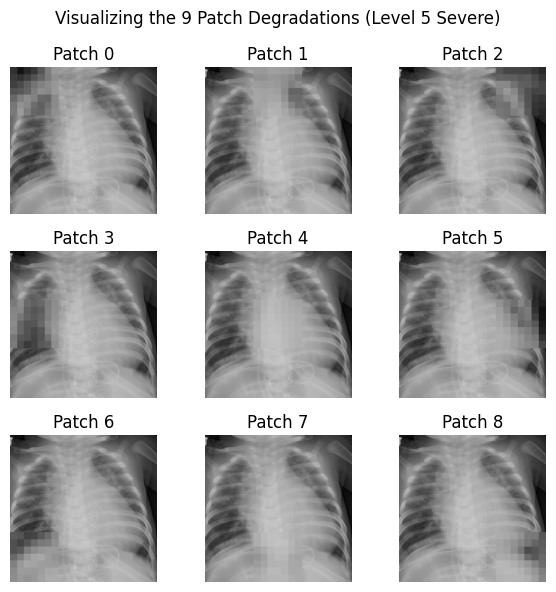

In [10]:
class PatchDegradationTransform:
    def __init__(self, patch_idx, downscale_size, grid_size=3):
        self.patch_idx = patch_idx
        self.downscale_size = downscale_size
        self.grid_size = grid_size
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(mean=MEAN, std=STD)

    def __call__(self, img):
        # Ensure base size and RGB
        img = img.resize((SIZE, SIZE), Image.NEAREST).convert('RGB')
        w, h = img.size

        # Calculate grid dimensions
        patch_w, patch_h = w // self.grid_size, h // self.grid_size
        r, c = self.patch_idx // self.grid_size, self.patch_idx % self.grid_size

        # Define patch boundaries (handle remainder pixels in the last row/col)
        left = c * patch_w
        upper = r * patch_h
        right = w if c == self.grid_size - 1 else (c + 1) * patch_w
        lower = h if r == self.grid_size - 1 else (r + 1) * patch_h

        # Crop, degrade, and upscale the specific patch
        patch = img.crop((left, upper, right, lower))
        patch = patch.resize((self.downscale_size, self.downscale_size), Image.BILINEAR)
        patch = patch.resize((right - left, lower - upper), Image.NEAREST)

        # Paste the corrupted patch back onto a clean copy of the image
        img_corrupted = img.copy()
        img_corrupted.paste(patch, (left, upper))

        return self.normalize(self.to_tensor(img_corrupted))

# Let's visualize the 9 patches on a single sample image
sample_img, _ = clean_ds[0] # Grab a sample from the dataset
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle('Visualizing the 9 Patch Degradations (Level 5 Severe)', fontsize=12)

# We will use Level 5 severity (7x7 downscale) to make the corruption obvious
severe_downscale = 7

# NOTE: clean_ds[0] returns a normalized tensor because of make_clean_transform.
# We need a raw PIL image to visualize our new transform properly before tensor conversion.
raw_ds = PneumoniaMNIST(split='test', transform=None, download=False, root=DATA_ROOT, size=SIZE)
pil_img, _ = raw_ds[0]

for idx in range(9):
    r, c = idx // 3, idx % 3
    transform_preview = PatchDegradationTransform(patch_idx=idx, downscale_size=severe_downscale)
    # Call the transform, but grab the image right before ToTensor for visualization
    # Re-implementing the inner logic briefly just for the plot:
    img_resized = pil_img.resize((SIZE, SIZE), Image.NEAREST).convert('RGB')
    pw, ph = SIZE // 3, SIZE // 3
    left, upper = c * pw, r * ph
    right, lower = SIZE if c == 2 else (c+1)*pw, SIZE if r == 2 else (r+1)*ph
    patch = img_resized.crop((left, upper, right, lower))
    patch = patch.resize((severe_downscale, severe_downscale), Image.BILINEAR).resize((right-left, lower-upper), Image.NEAREST)
    img_resized.paste(patch, (left, upper))

    axes[r, c].imshow(img_resized)
    axes[r, c].axis('off')
    axes[r, c].set_title(f'Patch {idx}')

plt.tight_layout()
plt.show()

Evaluating Patch Vulnerability at Severity Level 5 (Res=7)...
Evaluating patch 0/8...
Evaluating patch 1/8...
Evaluating patch 2/8...
Evaluating patch 3/8...
Evaluating patch 4/8...
Evaluating patch 5/8...
Evaluating patch 6/8...
Evaluating patch 7/8...
Evaluating patch 8/8...


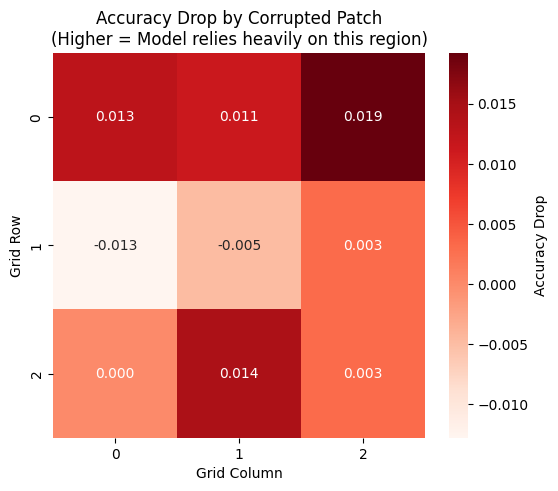

Baseline Accuracy: 0.8942
Worst Accuracy Drop: 0.0192 at patch index 2


In [11]:
print(f"Evaluating Patch Vulnerability at Severity Level 5 (Res={severe_downscale})...")
patch_results = []

for idx in range(9):
    print(f"Evaluating patch {idx}/8...")
    patch_transform = PatchDegradationTransform(patch_idx=idx, downscale_size=severe_downscale)
    loader, _ = make_loader(patch_transform)
    y_score, _ = run_inference(model, loader, device)
    metrics = compute_metrics(y_score, y_true, DATA_FLAG, SIZE)
    patch_results.append(metrics['accuracy'])

# Reshape results into a 3x3 grid for the heatmap
accuracy_grid = np.array(patch_results).reshape(3, 3)
baseline_acc = baseline['accuracy']
accuracy_drop_grid = baseline_acc - accuracy_grid

# Plot the heatmap
plt.figure(figsize=(6, 5))
import seaborn as sns
ax = sns.heatmap(accuracy_drop_grid, annot=True, fmt=".3f", cmap="Reds", cbar_kws={'label': 'Accuracy Drop'})
ax.set_title('Accuracy Drop by Corrupted Patch\n(Higher = Model relies heavily on this region)')
ax.set_xlabel('Grid Column')
ax.set_ylabel('Grid Row')
plt.show()

print("Baseline Accuracy:", round(baseline_acc, 4))
print("Worst Accuracy Drop:", round(np.max(accuracy_drop_grid), 4), "at patch index", np.argmax(accuracy_drop_grid))

### 9. Global Downscaling/Upscaling Transforms
Instead of localized degradation, we now simulate global resolution loss by downscaling the entire image to a small size and then upscaling it back to 224x224.

In [12]:
def make_scale_transform(downscale_size):
    """Simulates resolution degradation by downscaling and then upscaling back."""
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        # Downscale to lose information
        transforms.Resize((downscale_size, downscale_size), interpolation=Image.BILINEAR),
        # Upscale back to the required model input size
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

# ── Resolution severity levels ────────────────────────────────────────────────
# Level 1 = Half resolution, Level 5 = Extreme pixelation
SCALE_LEVELS = {
    1: 112,  # 1/2 of 224
    2: 56,   # 1/4 of 224
    3: 28,   # 1/8 of 224
    4: 14,   # 1/16 of 224
    5: 7,    # 1/32 of 224
}

print('Transforms defined.')
print('Scaling levels (downscale size):', SCALE_LEVELS)

Transforms defined.
Scaling levels (downscale size): {1: 112, 2: 56, 3: 28, 4: 14, 5: 7}


### 10. Evaluate Global Resolution Scaling
Let's evaluate the model across various scale levels to see exactly how global downscaling and upscaling impacts overall performance.

In [13]:
if 'SCALE_LEVELS' not in globals() or 'baseline' not in globals():
    print("\u26a0\ufe0f Error: Prerequisites not found. Please run the previous cells first (especially 'Setup & Imports', 'Compute Baseline Metrics', and 'Transforms').")
else:
    print("Evaluating Resolution Scaling (Downscale -> Upscale) Degradation...")
    scale_accuracies = []
    scale_levels_list = sorted(list(SCALE_LEVELS.keys()))
    resolutions = [SCALE_LEVELS[lvl] for lvl in scale_levels_list]

    for lvl in scale_levels_list:
        res = SCALE_LEVELS[lvl]
        print(f"Evaluating Scale Level {lvl} (Resolution: {res}x{res})...")
        transform = make_scale_transform(res)
        loader, _ = make_loader(transform)
        y_score_scale, _ = run_inference(model, loader, device)
        metrics = compute_metrics(y_score_scale, y_true, DATA_FLAG, SIZE)
        scale_accuracies.append(metrics['accuracy'])

    # Display the numerical results
    print("\n--- Resolution Degradation Robustness ---")
    print(f"Baseline (224x224):\tAccuracy: {baseline['accuracy']:.4f}")
    for res, acc in zip(resolutions, scale_accuracies):
        print(f"Resolution: {res}x{res}\tAccuracy: {acc:.4f}")

Evaluating Resolution Scaling (Downscale -> Upscale) Degradation...
Evaluating Scale Level 1 (Resolution: 112x112)...
Evaluating Scale Level 2 (Resolution: 56x56)...
Evaluating Scale Level 3 (Resolution: 28x28)...
Evaluating Scale Level 4 (Resolution: 14x14)...
Evaluating Scale Level 5 (Resolution: 7x7)...

--- Resolution Degradation Robustness ---
Baseline (224x224):	Accuracy: 0.8942
Resolution: 112x112	Accuracy: 0.8926
Resolution: 56x56	Accuracy: 0.8958
Resolution: 28x28	Accuracy: 0.8846
Resolution: 14x14	Accuracy: 0.8606
Resolution: 7x7	Accuracy: 0.7260


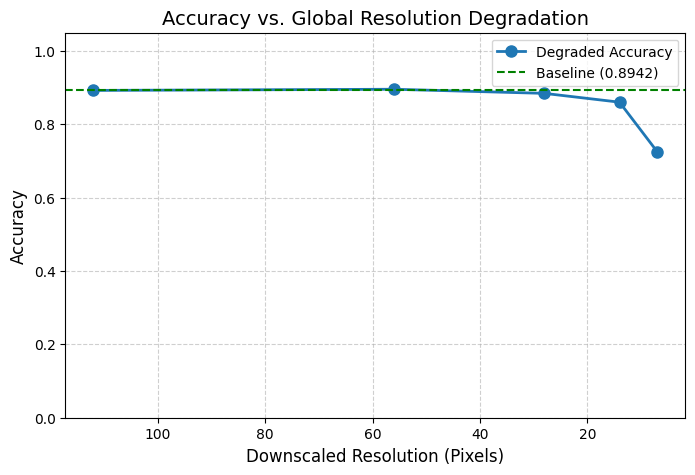

In [14]:
if 'scale_accuracies' not in globals() or not scale_accuracies or 'plt' not in globals():
    print("\u26a0\ufe0f Error: Please run the evaluation cell above and ensure previous import cells are run.")
else:
    # Plot the effect of scaling on Accuracy
    plt.figure(figsize=(8, 5))
    # We plot against resolution, so let's reverse the arrays to show decreasing resolution
    plt.plot(resolutions, scale_accuracies, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Degraded Accuracy')
    plt.axhline(y=baseline['accuracy'], color='green', linestyle='--', label=f'Baseline ({baseline["accuracy"]:.4f})')

    # Invert X axis so it goes from highest resolution (left) to lowest resolution (right)
    plt.gca().invert_xaxis()

    plt.title("Accuracy vs. Global Resolution Degradation", fontsize=14)
    plt.xlabel("Downscaled Resolution (Pixels)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, 1.05)
    plt.show()

### 10.5 Evaluate Upscaling Algorithms
We've seen that losing resolution hurts the model. But does the **upscaling algorithm** we use to bring the image back to 224x224 make a difference? Let's fix the downscale resolution to a low quality (e.g., 28x28) and try different interpolation methods to upscale it back.

Evaluating Upscaling Algorithms from a base resolution of 28x28...
Upscale Method: Nearest	Accuracy: 0.8846
Upscale Method: Bilinear	Accuracy: 0.8654
Upscale Method: Bicubic	Accuracy: 0.8798
Upscale Method: Lanczos	Accuracy: 0.8862


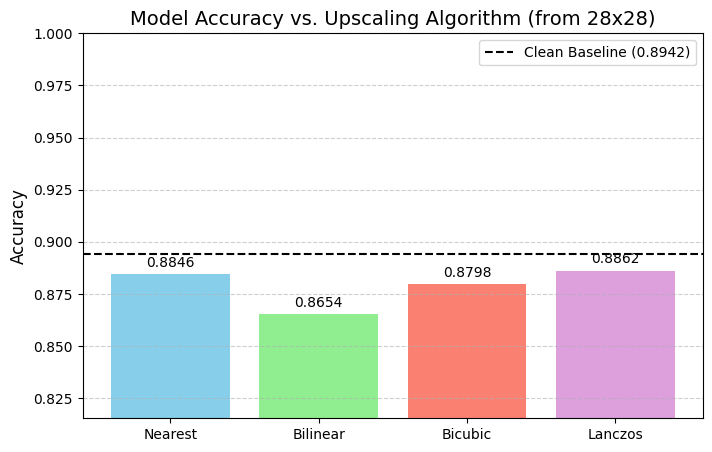

In [20]:
if 'baseline' not in globals():
    print("\u26a0\ufe0f Error: Please run the baseline evaluation cell first.")
else:
    # Dictionary of different upscaling algorithms from PIL
    upscale_methods = {
        'Nearest': Image.NEAREST,
        'Bilinear': Image.BILINEAR,
        'Bicubic': Image.BICUBIC,
        'Lanczos': Image.LANCZOS
    }

    fixed_downscale = 28  # Fix the degradation level
    upscale_accuracies = {}

    print(f"Evaluating Upscaling Algorithms from a base resolution of {fixed_downscale}x{fixed_downscale}...")

    for name, method in upscale_methods.items():
        transform = transforms.Compose([
            transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
            transforms.Lambda(lambda img: img.convert('RGB')),
            # Downscale to lose information (constant across all tests)
            transforms.Resize((fixed_downscale, fixed_downscale), interpolation=Image.BILINEAR),
            # Upscale back to 224x224 using the specific algorithm we are testing
            transforms.Resize((SIZE, SIZE), interpolation=method),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD)
        ])

        loader, _ = make_loader(transform)
        y_score_up, _ = run_inference(model, loader, device)
        metrics = compute_metrics(y_score_up, y_true, DATA_FLAG, SIZE)
        upscale_accuracies[name] = metrics['accuracy']
        print(f"Upscale Method: {name}\tAccuracy: {metrics['accuracy']:.4f}")

    # Plot the comparison
    plt.figure(figsize=(8, 5))
    methods = list(upscale_accuracies.keys())
    accuracies = list(upscale_accuracies.values())

    bars = plt.bar(methods, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
    plt.axhline(y=baseline['accuracy'], color='black', linestyle='--', label=f'Clean Baseline ({baseline["accuracy"]:.4f})')

    # Add values on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4), ha='center', va='bottom', fontsize=10)

    plt.title(f"Model Accuracy vs. Upscaling Algorithm (from {fixed_downscale}x{fixed_downscale})", fontsize=14)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(min(accuracies) - 0.05, 1.0) # Zoom in on the relevant accuracy range
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

### 11. Adversarial Attack Comparison (FGSM)
For contrast with resolution loss (downscaling), let's briefly see how the model handles highly targeted, imperceptible noise designed specifically to trick it.

In [15]:
import torch.nn.functional as F

def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon * sign_data_grad
    # Clip the perturbed image to maintain the normalized range [-1, 1]
    # (Since we normalized with mean 0.5, std 0.5, the range is roughly [-1, 1])
    perturbed_image = torch.clamp(perturbed_image, -1, 1)
    return perturbed_image

def run_fgsm_evaluation(model, loader, device, epsilon):
    all_scores, all_labels = [], []
    adv_examples = []

    for images, labels in loader:
        # Safely reshape labels to 1D for CrossEntropyLoss
        labels_sq = labels.view(-1).long().to(device)
        images = images.to(device)

        # Set requires_grad attribute of tensor. Important for Attack
        images.requires_grad = True

        # Forward pass
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels_sq)

        # Zero all existing gradients
        model.zero_grad()
        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect data_grad
        data_grad = images.grad.data

        # Call FGSM Attack
        perturbed_images = fgsm_attack(images, epsilon, data_grad)

        # Re-classify the perturbed image
        with torch.no_grad():
            adv_outputs = model(perturbed_images)
            scores = torch.softmax(adv_outputs, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())

            # Save a few examples for visualization (first batch only)
            if len(adv_examples) == 0:
                for i in range(min(5, len(images))):
                    adv_examples.append((images[i].detach().cpu(), perturbed_images[i].detach().cpu(), labels[i].item()))

    return np.concatenate(all_scores), np.concatenate(all_labels), adv_examples

print("FGSM attack logic defined.")

FGSM attack logic defined.


In [16]:
# Define epsilons (strength of the adversarial noise)
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
fgsm_accuracies = []
fgsm_examples = []

if 'clean_loader' not in globals():
    print("\u26a0\ufe0f Error: 'clean_loader' is not defined. Please run the '5.5 Compute Baseline Metrics' cell first.")
else:
    print("Evaluating FGSM Adversarial Attack...")
    for eps in epsilons:
        print(f"Running FGSM with epsilon = {eps}...")
        # We use the clean_loader for the attack baseline
        y_score_adv, y_true_adv, examples = run_fgsm_evaluation(model, clean_loader, device, eps)

        # Compute metrics
        metrics = compute_metrics(y_score_adv, y_true_adv, DATA_FLAG, SIZE)
        fgsm_accuracies.append(metrics['accuracy'])
        fgsm_examples.append(examples)

    print("\n--- FGSM Robustness ---")
    for eps, acc in zip(epsilons, fgsm_accuracies):
        print(f"Epsilon: {eps:.2f}\tAccuracy: {acc:.4f}")

Evaluating FGSM Adversarial Attack...
Running FGSM with epsilon = 0...
Running FGSM with epsilon = 0.05...
Running FGSM with epsilon = 0.1...
Running FGSM with epsilon = 0.15...
Running FGSM with epsilon = 0.2...
Running FGSM with epsilon = 0.25...
Running FGSM with epsilon = 0.3...

--- FGSM Robustness ---
Epsilon: 0.00	Accuracy: 0.8942
Epsilon: 0.05	Accuracy: 0.0080
Epsilon: 0.10	Accuracy: 0.0016
Epsilon: 0.15	Accuracy: 0.0016
Epsilon: 0.20	Accuracy: 0.0000
Epsilon: 0.25	Accuracy: 0.0000
Epsilon: 0.30	Accuracy: 0.0000


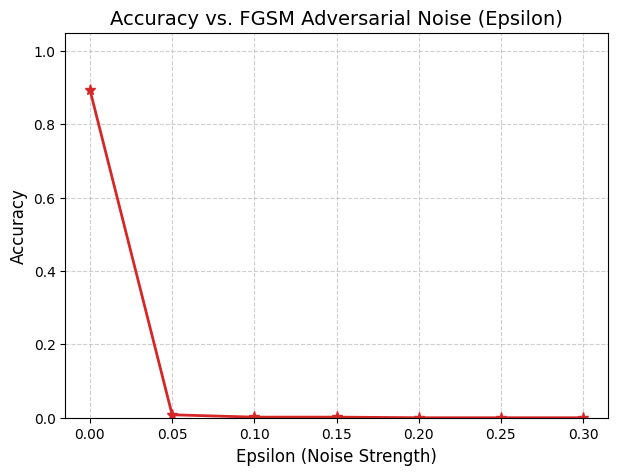

In [17]:
# Plot FGSM Degradation Curve
if len(fgsm_accuracies) > 0:
    plt.figure(figsize=(7, 5))
    plt.plot(epsilons, fgsm_accuracies, "*-", color='tab:red', linewidth=2, markersize=8)
    plt.title("Accuracy vs. FGSM Adversarial Noise (Epsilon)", fontsize=14)
    plt.xlabel("Epsilon (Noise Strength)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1.05)
    plt.show()
else:
    print("No FGSM accuracy data to plot. Please run the attack evaluation successfully first.")

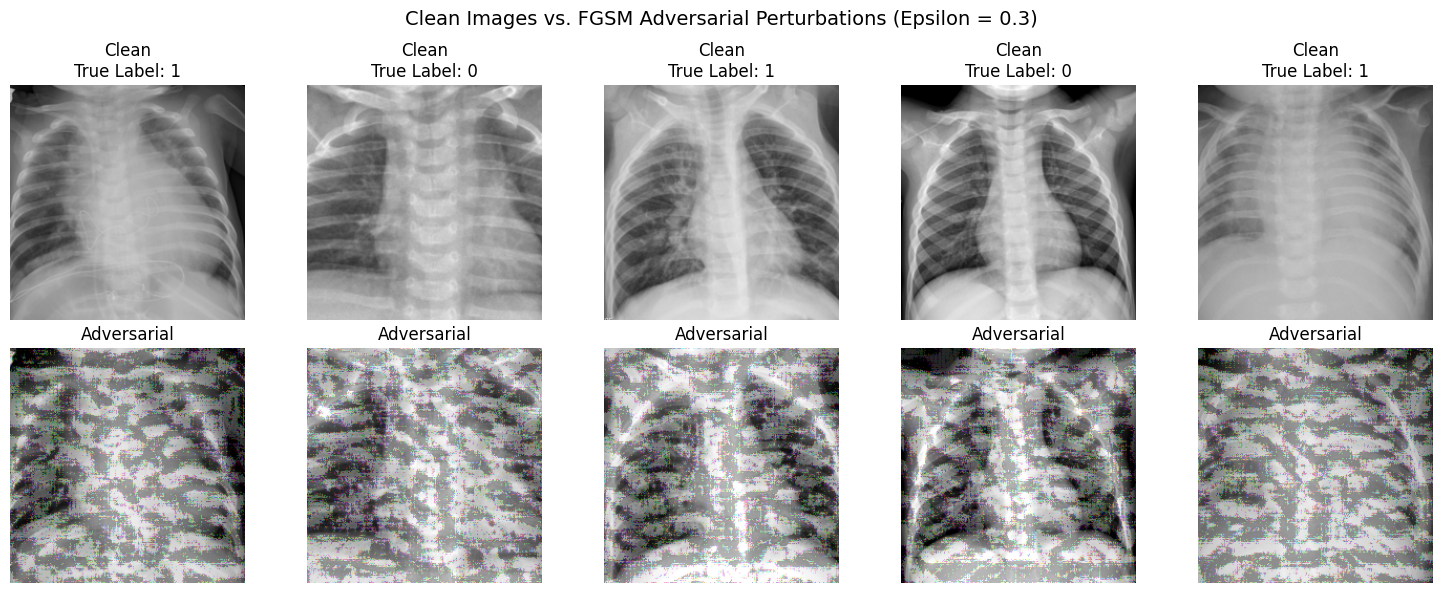

In [18]:
# Visualize some adversarial examples at the highest epsilon
if len(fgsm_examples) > 0:
    high_eps_idx = -1  # last epsilon (0.3)
    examples_to_plot = fgsm_examples[high_eps_idx]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f'Clean Images vs. FGSM Adversarial Perturbations (Epsilon = {epsilons[high_eps_idx]})', fontsize=14)

    for i, (orig, adv, label) in enumerate(examples_to_plot):
        # Un-normalize for display
        orig_display = orig.numpy().transpose(1, 2, 0) * 0.5 + 0.5
        adv_display = adv.numpy().transpose(1, 2, 0) * 0.5 + 0.5

        axes[0, i].imshow(orig_display)
        axes[0, i].set_title(f"Clean\nTrue Label: {label}")
        axes[0, i].axis('off')

        axes[1, i].imshow(adv_display)
        axes[1, i].set_title(f"Adversarial")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No adversarial examples to visualize. Please run the attack evaluation successfully first.")

### 12. Save All Results to Google Drive
Run this cell **after** you have executed all the experiments above to save the downscaling/upscaling metric data permanently.

In [21]:
# Package all the important metrics we calculated into a single dictionary
results_to_save = {}

if 'baseline' in globals():
    results_to_save['baseline'] = baseline

if 'patch_results' in globals():
    # Convert numpy types to native Python floats for JSON serialization
    results_to_save['patch_accuracies'] = [float(x) for x in patch_results]

if 'scale_accuracies' in globals():
    results_to_save['scale_accuracies'] = [float(x) for x in scale_accuracies]

if 'upscale_accuracies' in globals():
    results_to_save['upscale_accuracies'] = upscale_accuracies

# Save to Drive if we have anything to save
if results_to_save:
    save_results(results_to_save)
else:
    print("No results found in memory to save. Please run the analysis cells first.")

✅ Results successfully saved to: /content/drive/MyDrive/pneumonia_analysis_results.json
